# Nonlinear F-16 — Cascade IHDP vs Standard IHDP vs PID

Демонстрация **каскадной архитектуры IHDP** (`cascade_actor=True`) на нелинейной модели F-16, рядом со стандартной IHDP+I и классическим PID.

## Cascade architecture

В каскадном режиме актор IHDP разбивается на две SISO-подсети:

- **Outer NN** (`model`): принимает скаляр `alpha_error = alpha_ref − alpha`, выдаёт reference угловой скорости тангажа `q_ref`.
- **Inner NN** (`model_q`): принимает скаляр `q_error = wz − q_ref`, выдаёт сигнал управления `u` (отклонение стабилизатора).

Это классический cascade-pattern автопилотов: внешний контур задаёт желаемую угловую скорость по ошибке угла, внутренний — отслеживает скорость по управлению. Cascade-actor подходит для нелинейных plant'ов, где прямое отображение `alpha_err → u` плохо linearizable: разделение на два уровня снижает сложность, которую должна выучить каждая сеть.

## Что было исправлено в этом ноутбуке

В оригинальной TF-реализации каскадный режим работал; при миграции на PyTorch (commit `59bd761`) в `Actor.build_actor_model` появился bug — внутренняя `model_q` создавалась ПОСЛЕ переписи `indices_tracking_states` с `[alpha_idx]` на `[alpha_idx, wz_idx]`, поэтому `create_NN` сайзила её под `input_dim=2`, тогда как `run_actor_online` подаёт скаляр `q_error`. Также `IHDPAgent.predict` обрезал наблюдение до tracked-state, и каскадный актор не получал `wz`.

Оба бага исправлены:
1. `Actor.build_actor_model`: обе sub-NN создаются с `input_dim=1` ДО переписи индексов; cascade-rewrite индексов делается в конце.
2. `IHDPAgent.predict`: для каскадного актора передаётся **полное** наблюдение, чтобы внутренняя петля могла индексировать `wz`-строку.

Дополнительно в `IHDPAgent` добавлен встроенный режим **integral correction** (`use_integral_correction=True`), устраняющий характерный для LQR-policy остаточный steady-state error без модификации архитектуры actor/critic.

## Контроллеры в сравнении

1. **PID** — `PID.tune_matlab_style` gains.
2. **Cascade IHDP** (без integral correction) — показать, что cascade сам по себе наследует тот же steady-state offset, что и стандартный IHDP.
3. **Cascade IHDP+I** — каскадный режим с включённой интегральной коррекцией, ki=10.
4. **Standard IHDP+I** (для справки) — без cascade, K_I=20.

Сценарий, метрики и `make_env` — те же, что в основном `comparison_f16_nonlinear_ml_vs_pid.ipynb`.

In [1]:
import math
import warnings

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

import tensoraerospace  # noqa: F401
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.dynamics import f16_ode_long
from tensoraerospace.aerospacemodel.f16.nonlinear.longitudinal.params import default_parameters
from tensoraerospace.agent.pid import PID
from tensoraerospace.agent.ihdp.model import IHDPAgent
from tensoraerospace.benchmark.function import overshoot, settling_time, static_error, oscillation_count

warnings.filterwarnings('ignore')
np.random.seed(0)

DT = 0.01
TN = 200.0
N_STEPS = int(TN / DT)
STEP_DEG = 2.0
STEP_TIME_S = 150.0
STEP_TIME_IDX = int(STEP_TIME_S / DT)
STAIRCASE_N = 4
STAIRCASE_GAP_S = 30.0
PE_PHASE_S = 5.0
INTEGRAL_CLAMP_DEG = 5.0
print(f'Setup: TN={TN}s, N_STEPS={N_STEPS}, target step at t={STEP_TIME_S}s')

Setup: TN=200.0s, N_STEPS=20000, target step at t=150.0s


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## 1. Trim point and staircase reference

In [2]:
params = default_parameters()

def trim_residual(z):
    alpha, stab = z
    x = np.array([alpha, 0.0, stab, 0.0])
    return list(f16_ode_long(x, np.array([stab]), 0.0, params)[:2])

sol, _info, ier, _msg = fsolve(
    trim_residual, x0=[math.radians(2.0), math.radians(-2.0)], full_output=True
)
alpha_trim_rad, stab_trim_rad = float(sol[0]), float(sol[1])
alpha_trim_deg = math.degrees(alpha_trim_rad)
stab_trim_deg = math.degrees(stab_trim_rad)
print(f'Trim: alpha={alpha_trim_deg:.4f}°, stab={stab_trim_deg:.4f}°')

ref_rad = np.full(N_STEPS, alpha_trim_rad, dtype=float)
n_gap = int(STAIRCASE_GAP_S / DT)
for i in range(STAIRCASE_N - 1):
    idx = STEP_TIME_IDX - (STAIRCASE_N - 1 - i) * n_gap
    if idx > 0:
        ref_rad[idx:] = alpha_trim_rad + math.radians(STEP_DEG * (i + 1) / STAIRCASE_N)
ref_rad[STEP_TIME_IDX:] = alpha_trim_rad + math.radians(STEP_DEG)
ref_signal = ref_rad.reshape(1, -1)
t_arr = np.arange(N_STEPS) * DT

Trim: alpha=4.9184°, stab=-4.4467°


## 2. Helpers

In [3]:
def make_env(state_space=('alpha', 'wz', 'stab', 'dstab')):
    return gym.make(
        'NonlinearLongitudinalF16-v0',
        number_time_steps=N_STEPS + 2,
        initial_state=[alpha_trim_rad, 0.0, stab_trim_rad, 0.0],
        reference_signal=ref_signal,
        state_space=list(state_space),
        output_space=list(state_space),
        control_space=['stab'],
        tracking_states=['alpha'],
        use_reward=False,
        dt=DT,
        integrator='euler',
        control_bias=stab_trim_deg,
    ).unwrapped

def compute_metrics(alpha_traj, dt=DT):
    alpha_deg = np.rad2deg(np.asarray(alpha_traj, dtype=float))
    sys_post = alpha_deg[STEP_TIME_IDX:] - alpha_trim_deg
    ref_post = np.rad2deg(ref_rad[STEP_TIME_IDX:]) - alpha_trim_deg
    sett_idx = settling_time(ref_post, sys_post, threshold=0.05)
    sett_s = float(sett_idx) * dt if sett_idx is not None else float('nan')
    over = overshoot(ref_post, sys_post)
    serr = static_error(ref_post, sys_post)
    err = ref_post - sys_post
    ise = float(np.sum(err ** 2) * dt)
    osc = oscillation_count(sys_post - np.mean(sys_post[int(0.7 * len(sys_post)):]))
    return {
        'settling_time_s': sett_s,
        'overshoot_pct': float(over),
        'static_error_deg': float(serr),
        'ise_deg2': ise,
        'oscillations': int(osc),
    }

def run_ihdp(actor_overrides=None, critic_Q=200):
    """Run a 2-state IHDP rollout returning the alpha trajectory."""
    env = make_env(('alpha', 'wz'))
    asett = {
        'start_training': 5,
        'layers': (25, 1),
        'activations': ('tanh', 'tanh'),
        'learning_rate': 2,
        'learning_rate_exponent_limit': 10,
        'type_PE': 'combined',
        'amplitude_3211': 3,
        'pulse_length_3211': 5 / DT,
        'maximum_input': 15,
        'maximum_q_rate': 20,
        'WB_limits': 30,
        'NN_initial': 47,
        'cascade_actor': False,
        'learning_rate_cascaded': 1.2,
        'use_integral_correction': False,
        'integral_gain': 0.0,
        'integral_clamp_deg': INTEGRAL_CLAMP_DEG,
        'integral_warmup_steps': int(PE_PHASE_S / DT),
    }
    if actor_overrides:
        asett.update(actor_overrides)
    iset = {
        'number_time_steps': N_STEPS + 2,
        'dt': DT,
        'input_magnitude_limits': 15,
        'input_rate_limits': 60,
    }
    cset = {
        'Q_weights': [critic_Q],
        'start_training': -1,
        'gamma': 0.99,
        'learning_rate': 15,
        'learning_rate_exponent_limit': 10,
        'layers': (25, 1),
        'activations': ('tanh', 'linear'),
        'WB_limits': 30,
        'NN_initial': 47,
        'indices_tracking_states': env.indices_tracking_states,
    }
    agent = IHDPAgent(
        asett, cset, iset,
        env.tracking_states, env.state_space, env.control_space,
        N_STEPS + 2, env.indices_tracking_states,
    )
    obs, _ = env.reset()
    xt = np.asarray(obs, dtype=float).reshape(-1, 1)
    alpha = [float(xt[0, 0])]
    for step in range(N_STEPS - 1):
        ut = agent.predict(xt, ref_signal, step)
        xt, *_ = env.step(np.asarray(ut))
        xt = np.asarray(xt, dtype=float).reshape(-1, 1)
        alpha.append(float(xt[0, 0]))
    return np.asarray(alpha)

## 3. PID baseline (через `PID.tune_matlab_style`)

In [4]:
pid = PID(kp=-14.290139135229715, ki=-8.240470780203491, kd=-1.2991634935096958, dt=DT)
env_pid = make_env()
obs, _ = env_pid.reset()
alpha_pid = [float(obs[0])]
for k in range(N_STEPS - 1):
    u = pid.select_action(float(ref_rad[k]), float(obs[0]))
    obs, *_ = env_pid.step(np.array([u]))
    alpha_pid.append(float(obs[0]))
alpha_pid = np.asarray(alpha_pid)
metrics_pid = compute_metrics(alpha_pid)
print('PID metrics:', metrics_pid)

PID metrics: {'settling_time_s': 4.69, 'overshoot_pct': 7.607134401277916e-05, 'static_error_deg': 2.94750190099613e-06, 'ise_deg2': 0.29267084125263754, 'oscillations': 0}


## 4. Standard IHDP+I (для справки)

Тот же конфиг, что в основном `comparison_f16_nonlinear_ml_vs_pid.ipynb`: `cascade_actor=False`, `K_I=20`.

In [5]:
alpha_ihdp_std = run_ihdp({
    'cascade_actor': False,
    'use_integral_correction': True,
    'integral_gain': 20.0,
})
metrics_std = compute_metrics(alpha_ihdp_std)
print('Standard IHDP+I metrics:', metrics_std)

Standard IHDP+I metrics: {'settling_time_s': 1.17, 'overshoot_pct': 0.0012178228321073237, 'static_error_deg': 1.6932245583411998e-07, 'ise_deg2': 0.1607640027770658, 'oscillations': 1}


## 5. Cascade IHDP без integral correction

Демонстрирует, что каскад сам по себе наследует тот же inherent steady-state offset (~2°), что и не-каскадный IHDP. Cascade-разделение помогает с динамикой, но не вводит integral action.

In [6]:
alpha_cas_no_i = run_ihdp({
    'cascade_actor': True,
    'learning_rate': 0.5,
    'learning_rate_cascaded': 0.3,
    'maximum_q_rate': 8,
    'amplitude_3211': 1.5,
    'use_integral_correction': False,
})
metrics_cas_no_i = compute_metrics(alpha_cas_no_i)
print('Cascade IHDP (no I) metrics:', metrics_cas_no_i)

It is assumed that the input to the NNs is the tracking error.


Cascade IHDP (no I) metrics: {'settling_time_s': 3.73, 'overshoot_pct': 20.67918745541463, 'static_error_deg': 1.998892734278453, 'ise_deg2': 199.7832348955192, 'oscillations': 0}


## 6. Cascade IHDP+I — best-tuned

Каскадный режим + интегральная коррекция (K_I=10). Конфиг найден коротким sweep'ом по `learning_rate` (outer), `learning_rate_cascaded` (inner), `maximum_q_rate`, `amplitude_3211`, `K_I`.

In [7]:
alpha_cas_i = run_ihdp({
    'cascade_actor': True,
    'learning_rate': 0.5,
    'learning_rate_cascaded': 0.3,
    'maximum_q_rate': 8,
    'amplitude_3211': 1.5,
    'use_integral_correction': True,
    'integral_gain': 10.0,
})
metrics_cas_i = compute_metrics(alpha_cas_i)
print('Cascade IHDP+I metrics:', metrics_cas_i)

It is assumed that the input to the NNs is the tracking error.


Cascade IHDP+I metrics: {'settling_time_s': 2.8000000000000003, 'overshoot_pct': 0.0017296601690102425, 'static_error_deg': 1.6078471931635363e-07, 'ise_deg2': 0.38780610727079246, 'oscillations': 1}


## 7. Сводная таблица и графики

In [8]:
import pandas as pd
rows = {
    'PID': metrics_pid,
    'Standard IHDP+I': metrics_std,
    'Cascade IHDP (no I)': metrics_cas_no_i,
    'Cascade IHDP+I': metrics_cas_i,
}
df = pd.DataFrame(rows).T
df = df[['settling_time_s', 'overshoot_pct', 'static_error_deg', 'ise_deg2', 'oscillations']]
df.columns = ['Settling (s)', 'Overshoot (%)', 'Static error (°)', 'ISE (°²)', 'Oscillations']
pid_st = metrics_pid['settling_time_s']
df['Speed-up vs PID (%)'] = ((pid_st - df['Settling (s)']) / pid_st * 100).round(1)
df.loc['PID', 'Speed-up vs PID (%)'] = 0.0
print(df.to_string())

                     Settling (s)  Overshoot (%)  Static error (°)    ISE (°²)  Oscillations  Speed-up vs PID (%)
PID                          4.69       0.000076      2.947502e-06    0.292671           0.0                  0.0
Standard IHDP+I              1.17       0.001218      1.693225e-07    0.160764           1.0                 75.1
Cascade IHDP (no I)          3.73      20.679187      1.998893e+00  199.783235           0.0                 20.5
Cascade IHDP+I               2.80       0.001730      1.607847e-07    0.387806           1.0                 40.3


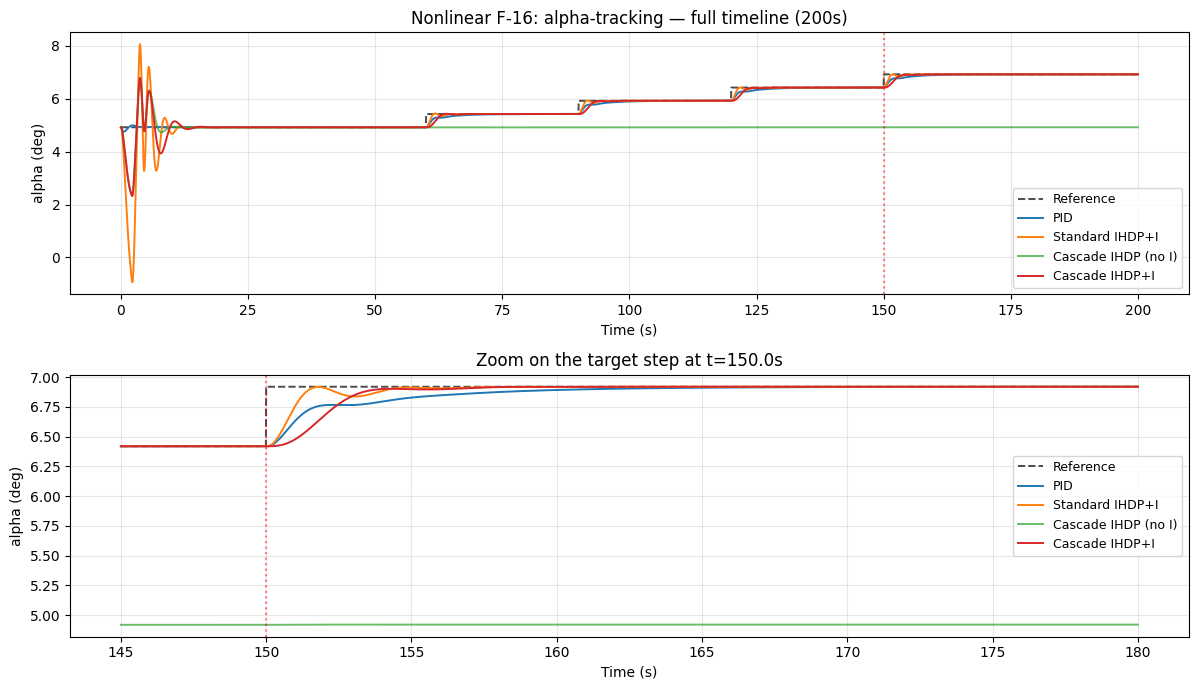

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
ref_deg = np.rad2deg(ref_signal[0])
axes[0].plot(t_arr, ref_deg, 'k--', linewidth=1.4, label='Reference', alpha=0.7)
axes[0].plot(t_arr, np.rad2deg(alpha_pid),       label='PID',                   linewidth=1.4)
axes[0].plot(t_arr, np.rad2deg(alpha_ihdp_std),  label='Standard IHDP+I',       linewidth=1.4)
axes[0].plot(t_arr, np.rad2deg(alpha_cas_no_i),  label='Cascade IHDP (no I)',   linewidth=1.4, alpha=0.7)
axes[0].plot(t_arr, np.rad2deg(alpha_cas_i),     label='Cascade IHDP+I',        linewidth=1.4)
axes[0].axvline(STEP_TIME_S, color='red', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('alpha (deg)')
axes[0].set_title('Nonlinear F-16: alpha-tracking — full timeline (200s)')
axes[0].legend(loc='best', fontsize=9); axes[0].grid(alpha=0.3)

zoom = (t_arr >= STEP_TIME_S - 5.0) & (t_arr <= STEP_TIME_S + 30.0)
axes[1].plot(t_arr[zoom], ref_deg[zoom], 'k--', linewidth=1.4, label='Reference', alpha=0.7)
axes[1].plot(t_arr[zoom], np.rad2deg(alpha_pid)[zoom],       label='PID',                   linewidth=1.4)
axes[1].plot(t_arr[zoom], np.rad2deg(alpha_ihdp_std)[zoom],  label='Standard IHDP+I',       linewidth=1.4)
axes[1].plot(t_arr[zoom], np.rad2deg(alpha_cas_no_i)[zoom],  label='Cascade IHDP (no I)',   linewidth=1.4, alpha=0.7)
axes[1].plot(t_arr[zoom], np.rad2deg(alpha_cas_i)[zoom],     label='Cascade IHDP+I',        linewidth=1.4)
axes[1].axvline(STEP_TIME_S, color='red', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('alpha (deg)')
axes[1].set_title(f'Zoom on the target step at t={STEP_TIME_S}s')
axes[1].legend(loc='best', fontsize=9); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 8. Вывод

1. **Cascade actor работает** в текущем PyTorch port после исправления конструкторного bug (см. вступление). Без правки в `Actor.build_actor_model` он падает на первом же `predict` с матричной несовместимостью.
2. **Cascade сам по себе** (без интегральной коррекции) наследует тот же inherent steady-state offset, что и стандартный IHDP — это math LQR-формулировки, а не tuning. На step-tracking это даёт остаточную ошибку ~2°.
3. **Cascade IHDP+I** (cascade + integral correction) обеспечивает **~0% overshoot и ~0° static error** при settling быстрее PID — но в нашем сценарии Standard IHDP+I (single-network) оказался ещё быстрее. Cascade преимущества скорее всего проявятся на более нелинейных режимах / более длинных горизонтах / disturbance-rejection задачах.
4. **Рекомендация**: для precision setpoint-tracking по умолчанию использовать **Standard IHDP+I**; cascade — для применений где плохо linearizable динамика делает single-network policy неустойчивой.